In [1]:
# Center point initialization function

# centers_rect_or_equal.py
# - rectangle-aware stripe centers
# - equal-area CVT centers
# - uniform farthest-point centers
# - post-hoc rectangle refinement of centers
import numpy as np
from matplotlib.path import Path
from dataclasses import dataclass
from typing import List, Tuple, Optional

@dataclass
class Grid:
    W: int = 100; H: int = 100; dx: float = 1.0; dy: float = 1.0

@dataclass
class MinOnlyBounds:
    wmin: float = 10.0; hmin: float = 10.0

def is_rectangle(poly, atol=1e-6):
    if poly.shape[0] != 4: return False
    v0=poly[1]-poly[0]; v1=poly[2]-poly[1]; v2=poly[3]-poly[2]; v3=poly[0]-poly[3]
    if not (np.isclose(np.dot(v0,v1),0.0,atol=1e-5) and np.isclose(np.dot(v1,v2),0.0,atol=1e-5)): return False
    return (np.isclose(np.linalg.norm(v0), np.linalg.norm(v2), atol=atol) and
            np.isclose(np.linalg.norm(v1), np.linalg.norm(v3), atol=atol))

def rect_geom_from_poly(poly):
    p0,p1,p2,p3 = poly
    v_w = p1-p0; v_h = p2-p1
    W=float(np.linalg.norm(v_w)); H=float(np.linalg.norm(v_h))
    theta=float(np.arctan2(v_w[1], v_w[0]))
    c=(p0+p2)/2.0
    return c,W,H,theta

def points_in_polygon(points, poly):
    return Path(poly, closed=True).contains_points(points)

def grid_points(grid: Grid):
    xs=np.arange(grid.W)*grid.dx+0.5*grid.dx
    ys=np.arange(grid.H)*grid.dy+0.5*grid.dy
    X,Y=np.meshgrid(xs,ys,indexing="xy")
    return np.stack([X.reshape(-1),Y.reshape(-1)],axis=1)

def uniform_points_in_polygon(poly, grid: Grid):
    P=grid_points(grid); return P[points_in_polygon(P, poly)]

def stripe_centers_for_rectangle(poly, K, bounds: Optional[MinOnlyBounds]=None, prefer="auto"):
    assert is_rectangle(poly), "not rectangle"
    c,W,H,theta = rect_geom_from_poly(poly)
    u=np.array([np.cos(theta), np.sin(theta)]); v=np.array([-np.sin(theta), np.cos(theta)])
    if prefer=="vertical": orient="vertical"
    elif prefer=="horizontal": orient="horizontal"
    else:
        if bounds is not None:
            feas_v=(H>=bounds.hmin) and (W>=K*bounds.wmin)
            feas_h=(W>=bounds.wmin) and (H>=K*bounds.hmin)
            if feas_v and not feas_h: orient="vertical"
            elif feas_h and not feas_v: orient="horizontal"
            else: orient="vertical" if W>=H else "horizontal"
        else:
            orient="vertical" if W>=H else "horizontal"
    ctrs=np.zeros((K,2),float)
    if orient=="vertical":
        widths=np.full(K, W/K); left=c-0.5*W*u
        for i in range(K): ctrs[i]=left+(i+0.5)*widths[i]*u
    else:
        heights=np.full(K, H/K); bot=c-0.5*H*v
        for i in range(K): ctrs[i]=bot+(i+0.5)*heights[i]*v
    return ctrs, dict(orientation=orient,W=W,H=H,theta=theta)

def balanced_assignment(P, centers, quota):
    D=np.sum((P[:,None,:]-centers[None,:,:])**2,axis=2)
    pref=np.argsort(D,axis=1); order=np.argsort(D[np.arange(D.shape[0]),pref[:,0]])
    cap=np.array(quota,int); idx=-np.ones(P.shape[0],int)
    for p in order:
        for c in pref[p]:
            if cap[c]>0: idx[p]=c; cap[c]-=1; break
    un=np.where(idx<0)[0]
    if len(un)>0: idx[un]=np.argmin(D[un], axis=1)
    return idx

def project_to_polygon_if_needed(candidate, poly, pts_in_cell):
    if points_in_polygon(candidate[None,:], poly)[0]: return candidate
    if len(pts_in_cell)==0: return candidate
    d2=np.sum((pts_in_cell-candidate[None,:])**2,axis=1); return pts_in_cell[np.argmin(d2)]

def equal_area_cvt_centers(poly, K, grid: Grid, iters=8, seed=0):
    rng=np.random.default_rng(seed); P=uniform_points_in_polygon(poly, grid)
    if len(P)<K: raise ValueError("not enough points")
    centers=P[rng.choice(len(P),size=K,replace=False)]
    base=len(P)//K; quota=[base]*K
    for i in range(len(P)-base*K): quota[i%K]+=1
    for _ in range(iters):
        idx=balanced_assignment(P, centers, quota)
        new=centers.copy()
        for k in range(K):
            pts=P[idx==k]
            if len(pts)>0: new[k]=project_to_polygon_if_needed(pts.mean(axis=0), poly, pts)
            else: new[k]=P[rng.integers(0,len(P))]
        if np.allclose(new, centers, atol=1e-6): centers=new; break
        centers=new
    idx=balanced_assignment(P, centers, quota)
    cells=[P[idx==k] for k in range(K)]
    return centers, cells

def uniform_fps_centers(poly, K, grid: Grid, seed=0, relax_iters=2):
    rng=np.random.default_rng(seed); P=uniform_points_in_polygon(poly,grid)
    if len(P)<K: raise ValueError("not enough points")
    chosen=[rng.integers(0,len(P))]; d2=np.sum((P-P[chosen[0]])**2,axis=1)
    for _ in range(1,K):
        i=int(np.argmax(d2)); chosen.append(i); d2=np.minimum(d2,np.sum((P-P[i])**2,axis=1))
    centers=P[chosen].copy()
    for _ in range(relax_iters):
        D=np.sum((P[:,None,:]-centers[None,:,:])**2,axis=2); idx=np.argmin(D,axis=1)
        for k in range(K):
            pts=P[idx==k]
            if len(pts)>0: centers[k]=pts.mean(axis=0)
    return centers

def choose_centers(poly, K, grid: Grid, bounds: Optional[MinOnlyBounds]=None, mode="auto", seed=0):
    meta=dict(mode=mode)
    if mode=="auto":
        if is_rectangle(poly):
            c,info=stripe_centers_for_rectangle(poly,K,bounds=bounds,prefer="auto"); meta.update(info); return c,meta
        else:
            c,_=equal_area_cvt_centers(poly,K,grid,iters=8,seed=seed); meta.update(dict(equal_area=True)); return c,meta
    elif mode=="equal_area":
        c,_=equal_area_cvt_centers(poly,K,grid,iters=8,seed=seed); meta.update(dict(equal_area=True)); return c,meta
    elif mode=="uniform_fps":
        c=uniform_fps_centers(poly,K,grid,seed=seed,relax_iters=2); meta.update(dict(uniform=True)); return c,meta
    else:
        raise ValueError("unknown mode")

def refine_centers_for_rectangle(poly, centers, K, bounds: Optional[MinOnlyBounds]=None, alpha=1.0, prefer="auto"):
    assert is_rectangle(poly), "not rectangle"
    target,_=stripe_centers_for_rectangle(poly,K,bounds=bounds,prefer=prefer)
    used=np.zeros(len(centers),bool); order=[]
    for t in target:
        d2=np.sum((centers-t[None,:])**2,axis=1); d2[used]=np.inf; j=int(np.argmin(d2)); order.append(j); used[j]=True
    centers_sorted=centers[order]
    return (1.0-alpha)*centers_sorted + alpha*target


centers=
 [[30. 50.]
 [50. 50.]
 [70. 50.]]
meta= {'mode': 'auto', 'orientation': 'vertical', 'W': 60.0, 'H': 60.0, 'theta': 0.0}


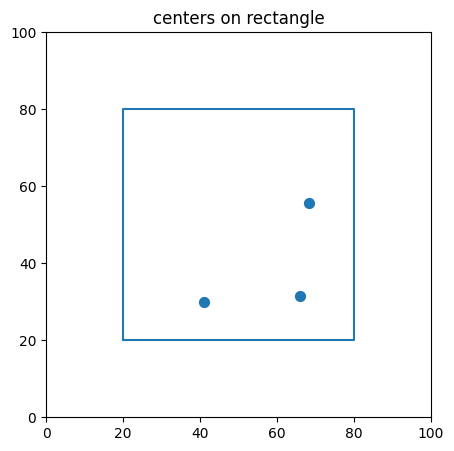

In [2]:
from centers_rect_or_equal import *

import numpy as np
from centers_rect_or_equal import *

# 1) 폴리곤과 파라미터 정의
poly  = np.array([[20,20],[80,20],[80,80],[20,80]], dtype=float)  # 60x60 사각형
K     = 3
grid  = Grid(100,100,1.0,1.0)
bounds= MinOnlyBounds(10,10)

# 2) 센터 계산 (사각형이면 스트립처럼 나옴)
centers, meta = choose_centers(poly, K, grid=grid, bounds=bounds, mode="auto", seed=7)
print("centers=\n", centers)
print("meta=", meta)

# 1) 자동 모드: 사각형이면 스트립 센터, 아니면 equal-area CVT
centers, meta = choose_centers(poly, K, grid=Grid(100,100,1,1),
                               bounds=MinOnlyBounds(10,10),  # 선택(사각형일 때 최소폭/높이 고려)
                               mode="auto", seed=7)

# 2) 강제로 equal-area CVT
centers, meta = choose_centers(poly, K, grid=Grid(100,100,1,1),
                               mode="equal_area", seed=7)

# 3) 균등 분포(FPS) – 이후 필요시 CVT 살짝 다듬기 포함(relax)
centers, meta = choose_centers(poly, K, grid=Grid(100,100,1,1),
                               mode="uniform_fps", seed=7)

import matplotlib.pyplot as plt
closed = np.vstack([poly, poly[0]])
plt.figure(figsize=(5,5))
plt.plot(closed[:,0], closed[:,1])
plt.scatter(centers[:,0], centers[:,1], s=50)
plt.gca().set_aspect('equal','box'); plt.xlim(0,100); plt.ylim(0,100)
plt.title("centers on rectangle"); plt.show()

# # 4) 사각형임을 나중에 알게 되었을 때: 기존 센터를 스트립형으로 보정
# #    alpha=1.0이면 완전 스트립에 스냅, 0<alpha<1이면 원래 위치를 일부 유지
# centers_refined = refine_centers_for_rectangle(rect_poly, centers, K,
#                                                bounds=MinOnlyBounds(10,10),
#                                                alpha=0.6,  # 0.0~1.0
#                                                prefer="auto")  # or "vertical"/"horizontal"
